# 1. Agentes con Memoria Conversacional en LangChain

## Objetivos de Aprendizaje
- Comprender por qué la memoria es crucial para crear agentes conversacionales efectivos.
- Aprender a gestionar el historial de una conversación (`chat_history`) con el `AgentExecutor`.
- Implementar un agente que recuerde interacciones pasadas para responder preguntas de seguimiento.
- Entender cómo LangChain pasa el contexto de la conversación al LLM.

## ¿Qué es la Memoria y Por Qué es Importante?

Por defecto, los LLMs y los agentes que hemos construido hasta ahora **no tienen estado (stateless)**. Cada vez que los invocamos, procesan la solicitud como si fuera la primera vez que interactúan con nosotros. No tienen recuerdo de preguntas o respuestas anteriores.

Esto es una gran limitación para crear asistentes o chatbots útiles. Un usuario espera poder hacer preguntas de seguimiento, referirse a información mencionada previamente y tener una conversación fluida. 

La **memoria** es el mecanismo que permite a un agente recordar interacciones pasadas. LangChain facilita enormemente la gestión de esta memoria. La forma más común de memoria es el **historial de chat (chat history)**, donde simplemente guardamos la lista de todos los mensajes de la conversación.

En este notebook, veremos cómo añadir esta capacidad a nuestro agente de LangChain.

### 1. Instalación y Configuración

In [ ]:
!pip install langchain langchain-openai openai wikipedia -q

In [1]:
# Celda 2: Importaciones y configuración
import os
from openai import OpenAI
import json

# Importar las bibliotecas necesarias
from groq import Groq
from dotenv import load_dotenv
from openai import OpenAI
import os

# load .env
load_dotenv()


# Verificar que tenemos las bibliotecas correctas
print("OpenAI library version:", __import__('openai').__version__)
print("Python version:", __import__('sys').version)


print("✅ Librerías importadas correctamente")

OpenAI library version: 2.29.0
Python version: 3.11.15 | packaged by Anaconda, Inc. | (main, Mar 11 2026, 17:12:15) [MSC v.1942 64 bit (AMD64)]
✅ Librerías importadas correctamente


In [3]:
import os
import wikipedia
from langchain_openai import ChatOpenAI

# Configurar el idioma de Wikipedia
wikipedia.set_lang("es")

# Configuración del LLM
try:
    llm = ChatOpenAI(
        model="gpt-4o",
        openai_api_base=os.environ.get("GITHUB_BASE_URL"),
        openai_api_key=os.environ.get("GITHUB_TOKEN"),
        temperature=0
    )
    print("✅ LLM de LangChain configurado.")
except Exception as e:
    print(f"❌ Error configurando el LLM: {e}")
    llm = None

✅ LLM de LangChain configurado.


### 2. Herramientas y Agente (Sin Cambios)

La definición de las herramientas y la creación del agente son exactamente las mismas que en el notebook anterior. La magia de la memoria no está en la definición del agente, sino en **cómo lo ejecutamos**.

In [4]:
from langchain_core.tools import tool
from langgraph.prebuilt import create_react_agent

@tool
def get_wikipedia_summary(query: str) -> str:
    """Busca en Wikipedia un tema y devuelve un resumen de 2 frases."""
    try:
        return wikipedia.summary(query, sentences=2)
    except Exception as e:
        return f"Ocurrió un error: {e}"

tools = [get_wikipedia_summary]

# Crear agente con LangGraph (reemplaza AgentExecutor)
agent_executor = create_react_agent(llm, tools)

print("✅ Agente y herramientas listos.")

✅ Agente y herramientas listos.


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_23616\2951874697.py:15: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  agent_executor = create_react_agent(llm, tools)


In [5]:
from langchain_core.tools import tool
from langgraph.prebuilt import create_react_agent

@tool
def get_wikipedia_summary(query: str) -> str:
    """Busca en Wikipedia un tema y devuelve un resumen de 2 frases."""
    try:
        return wikipedia.summary(query, sentences=2)
    except Exception as e:
        return f"Ocurrió un error: {e}"

tools = [get_wikipedia_summary]

# Crear agente con LangGraph (reemplaza AgentExecutor)
agent_executor = create_react_agent(llm, tools)

print("✅ Agente y herramientas listos.")

✅ Agente y herramientas listos.


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_23616\2951874697.py:15: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  agent_executor = create_react_agent(llm, tools)


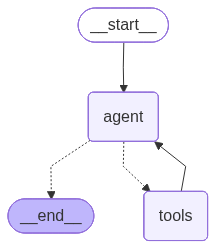

In [6]:
agent_executor

### 3. Gestionando la Memoria Conversacional

Para que el agente recuerde, necesitamos hacer dos cosas:

1.  **Mantener un historial**: Crearemos una lista llamada `chat_history` para almacenar los mensajes.
2.  **Pasar el historial en cada llamada**: El `AgentExecutor` acepta un parámetro `chat_history`. LangChain se encarga de formatear esta lista y añadirla al prompt que se envía al LLM.

El formato del historial es una lista de objetos `BaseMessage` de LangChain. Los más comunes son `HumanMessage` (para el usuario) y `AIMessage` (para la respuesta del agente).

In [19]:
from langchain_core.messages import HumanMessage, AIMessage

# Iniciamos el historial de chat como una lista vacía
chat_history = []

#### Primera Interacción: Sin Historial

In [20]:
query1 = "Háblame del planeta Saturno"

response1 = agent_executor.invoke({
    "messages": [{"role": "user", "content": query1}]
})

print(f"Respuesta 1: {response1['messages'][-1].content}")

c:\Users\Lenovo\anaconda3\envs\rag_env\Lib\site-packages\wikipedia\wikipedia.py:389: GuessedAtParserWarning: No parser was explicitly specified, so I'm using the best available HTML parser for this system ("html.parser"). This usually isn't a problem, but if you run this code on another system, or in a different virtual environment, it may use a different parser and behave differently.

The code that caused this warning is on line 389 of the file c:\Users\Lenovo\anaconda3\envs\rag_env\Lib\site-packages\wikipedia\wikipedia.py. To get rid of this warning, pass the additional argument 'features="html.parser"' to the BeautifulSoup constructor.

  lis = BeautifulSoup(html).find_all('li')


Respuesta 1: Saturno puede referirse a varios temas, como el planeta, la mitología, lugares, arte, tecnología, entre otros. ¿Te interesa específicamente el planeta Saturno?


Ahora, actualizamos manualmente nuestro historial con la pregunta del usuario y la respuesta del agente.

In [21]:
chat_history.append(HumanMessage(content=query1))
chat_history.append(AIMessage(content=response1['messages'][-1].content))

print("Historial actualizado.")

Historial actualizado.


In [22]:
chat_history

[HumanMessage(content='Háblame del planeta Saturno', additional_kwargs={}, response_metadata={}),
 AIMessage(content='Saturno puede referirse a varios temas, como el planeta, la mitología, lugares, arte, tecnología, entre otros. ¿Te interesa específicamente el planeta Saturno?', additional_kwargs={}, response_metadata={}, tool_calls=[], invalid_tool_calls=[])]

#### Segunda Interacción: Con Historial

Ahora hacemos una pregunta de seguimiento. Fíjate que no mencionamos "Saturno", simplemente preguntamos "¿de qué están hechos sus anillos?"

In [24]:
query2 = "¿Y de qué están hechos sus anillos?"

chat_history.append(HumanMessage(content=query2))


In [25]:
chat_history

[HumanMessage(content='Háblame del planeta Saturno', additional_kwargs={}, response_metadata={}, id='9c2f9ec4-c54e-4ef3-b4ea-120cdc92bf74'),
 AIMessage(content='Saturno puede referirse a varios temas, como el planeta, la mitología, lugares, arte, tecnología, entre otros. ¿Te interesa específicamente el planeta Saturno?', additional_kwargs={}, response_metadata={}, id='ad51fa3e-32f9-4107-87b8-b6df98f0909b', tool_calls=[], invalid_tool_calls=[]),
 HumanMessage(content='¿Y de qué están hechos sus anillos?', additional_kwargs={}, response_metadata={})]

In [26]:
response2 = agent_executor.invoke({
    "messages": chat_history
})



print(f"Respuesta 2: {response2['messages'][-1].content}")

Respuesta 2: Saturno es el sexto planeta del sistema solar y es conocido por sus impresionantes anillos. Sin embargo, el término "Saturno" puede referirse a otros temas, como mitología, arte, tecnología, entre otros.

En cuanto a los anillos de Saturno, son un sistema de siete anillos planetarios que rodean al planeta. Fueron observados por primera vez en julio de 1610 por Galileo Galilei, aunque inicialmente pensó que las estructuras borrosas que veía eran satélites cercanos al planeta. Los anillos están compuestos principalmente de partículas de hielo y roca, que varían en tamaño desde pequeños granos hasta fragmentos más grandes.


¡Funcionó! El agente entendió que "sus anillos" se refería a los anillos de Saturno, porque la conversación anterior estaba en su contexto. El `verbose=True` nos muestra que el agente decidió buscar en Wikipedia "anillos de Saturno", combinando la nueva pregunta con el historial.

## Conclusiones

Añadir memoria a un agente de LangChain es sorprendentemente sencillo, pero increíblemente poderoso. Simplemente manteniendo una lista del historial de chat y pasándola en cada invocación, transformamos un agente de una sola respuesta en un verdadero **asistente conversacional**.

La clave es que los componentes de LangChain (`AgentExecutor`, los prompts de `hub`) ya están diseñados para buscar y utilizar la variable `chat_history` si se proporciona.

**Limitaciones:**
- **Gestión Manual**: En este ejemplo, actualizamos la lista `chat_history` manualmente. Para una aplicación real, querríamos encapsular esto en una clase o función.
- **Tamaño del Contexto**: Enviar el historial completo en cada llamada puede volverse costoso y exceder el límite de tokens del modelo en conversaciones muy largas.

En los próximos notebooks, exploraremos los **sistemas de memoria** que LangChain ofrece para gestionar estas limitaciones, como la memoria de búfer (`BufferMemory`) que automatiza la gestión del historial y la memoria de resumen (`SummaryMemory`) que condensa conversaciones largas para ahorrar tokens.